<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Japan%20Birth%20Statistics%20(1899%E2%80%932023).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Japan Birth Statistics (1899–2023)

This analysis of Japan's birth statistics from 1899 to 2023 reveals a compelling and concerning demographic narrative, illustrating not just a decline in birth rates but a complex interplay of biological, societal, and economic factors.

Initially, a statistical examination of the sex ratio at birth indicates a slight, yet statistically significant, deviation from the biological standard of 105 males per 100 females. Japan's historical average of approximately 105.31 suggests a subtle, but mathematically distinct, pattern.

Delving into generational shocks, a Z-score analysis of total births identifies distinct periods of 'Baby Booms' and 'Population Collapses'. Notable boom years include the post-WWII era (1947-1950), while recent years (2017-2023) show a clear trend of population collapse, with a staggering 7 such years identified in rapid succession.

Perhaps the most striking finding is the structural decay of fertility rates. A Pearson correlation analysis for the post-1950 era reveals a severe negative correlation between the year and the total fertility rate (-0.8543). This signifies a persistent and almost linear collapse in the number of children women are having, moving far below the 2.1 replacement level needed to maintain a stable population. This decay is not cyclical; it's deeply ingrained.

The velocity of collapse further underscores the severity. Analyzing year-over-year momentum shows that in recent decades, the average change in birth rates has been consistently negative, indicating an accelerating contraction of the population. A structural break analysis also points to a period of lowest volatility, suggesting a prolonged era of demographic stagnation.

Time-series forecasting using an ARIMA model projects a continuation of this trend, estimating around 746,134 births in 2043. This forecast, built on historical patterns, paints a stark picture of future demographic challenges.

Further non-parametric tests confirm these insights: Kendall's Tau reveals a statistically significant monotonic downward trend in the crude birth rate. The Ljung-Box test for temporal memory confirms strong autocorrelation, implying that past demographic declines are highly predictive of future ones—a 'collapse today mathematically guarantees a collapse tomorrow.'

Finally, a Machine Learning model, specifically a Random Forest Regressor, was trained to predict next year's total births. The model achieved a Mean Absolute Percentage Error (MAPE) of 18.76%, meaning its predictions are within an 18.76% margin of error. Crude birth rate, the year itself, and male birth numbers were identified as the most important features driving these predictions, highlighting the multifaceted nature of Japan's demographic trajectory.

In essence, the data paints a picture of a nation grappling with a profound and accelerating demographic shift, characterized by sustained declines in birth rates and fertility, with significant implications for its future.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d hideos/japan-birth-statistics-18992023

# Unziping the downloaded file
!unzip japan-birth-statistics-18992023.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hideos/japan-birth-statistics-18992023
License(s): apache-2.0
  0% 0.00/2.73k [00:00<?, ?B/s]
100% 2.73k/2.73k [00:00<00:00, 8.83MB/s]
Archive:  japan-birth-statistics-18992023.zip
  inflating: japan_birth_statistics_1899_2023.csv  


# Data Inspection

In [4]:
df= pd.read_csv('japan_birth_statistics_1899_2023.csv')
df.head(11)

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
0,2023,727288,372603,354685,6.0,105.1,1.20
1,2022,770759,395257,375502,6.3,105.3,1.26
2,2021,811622,415903,395719,6.6,105.1,1.30
3,2020,840835,430713,410122,6.8,105.0,1.33
4,2019,865239,443430,421809,7.0,105.1,1.36
5,2018,918400,470851,447549,7.4,105.2,1.42
6,2017,946146,484478,461668,7.6,104.9,1.43
7,2016,977242,502012,475230,7.8,105.6,1.44
8,2015,1005721,515468,490253,8.0,105.1,1.45
9,2014,1003609,515572,488037,8.0,105.6,1.42


In [5]:
df.tail(11)

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
111,1909,1693850,863855,829995,34.9,104.1,NaN
112,1908,1662815,850209,812606,34.7,104.6,NaN
113,1907,1614472,818114,796358,34.0,102.7,NaN
114,1906,1394295,726155,668140,29.6,108.7,NaN
115,1905,1452770,735948,716822,31.2,102.7,NaN
116,1904,1440371,738230,702141,31.2,105.1,NaN
117,1903,1489816,763806,726010,32.7,105.2,NaN
118,1902,1510835,773296,737539,33.6,104.8,NaN
119,1901,1501591,769494,732097,33.9,105.1,NaN
120,1900,1420534,727916,692618,32.4,105.1,NaN


In [7]:
df.shape

(122, 7)

In [8]:
df.columns

Index(['year', 'total_births', 'male_births', 'female_births',
       'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate'],
      dtype='object')

In [9]:
df.dtypes

,0
year,int64
total_births,int64
male_births,int64
female_births,int64
crude_birth_rate,float64
sex_ratio_at_birth,float64
total_fertility_rate,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  122 non-null    int64  
 1   total_births          122 non-null    int64  
 2   male_births           122 non-null    int64  
 3   female_births         122 non-null    int64  
 4   crude_birth_rate      122 non-null    float64
 5   sex_ratio_at_birth    122 non-null    float64
 6   total_fertility_rate  77 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 6.8 KB


In [11]:
df.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
year,122.0,1.961393e+03,36.585812,1899.0,1929.250,1962.50,1992.750,2023.00
total_births,122.0,1.619319e+06,439286.360806,727288.0,1212138.000,1656495.00,1985485.500,2696638.00
male_births,122.0,8.304865e+05,224926.109670,372603.0,623344.750,849471.00,1014098.250,1380008.00
female_births,122.0,7.888323e+05,214416.989182,354685.0,588793.250,805848.00,967350.000,1316630.00
crude_birth_rate,122.0,2.082459e+01,10.534323,6.0,9.825,18.60,32.375,36.20
sex_ratio_at_birth,122.0,1.053107e+02,0.858387,102.7,104.900,105.30,105.800,108.70
total_fertility_rate,77.0,1.860779e+00,0.696069,1.2,1.390,1.72,2.050,4.54


In [13]:
df.isnull().sum()

,0
year,0
total_births,0
male_births,0
female_births,0
crude_birth_rate,0
sex_ratio_at_birth,0
total_fertility_rate,45


In [14]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

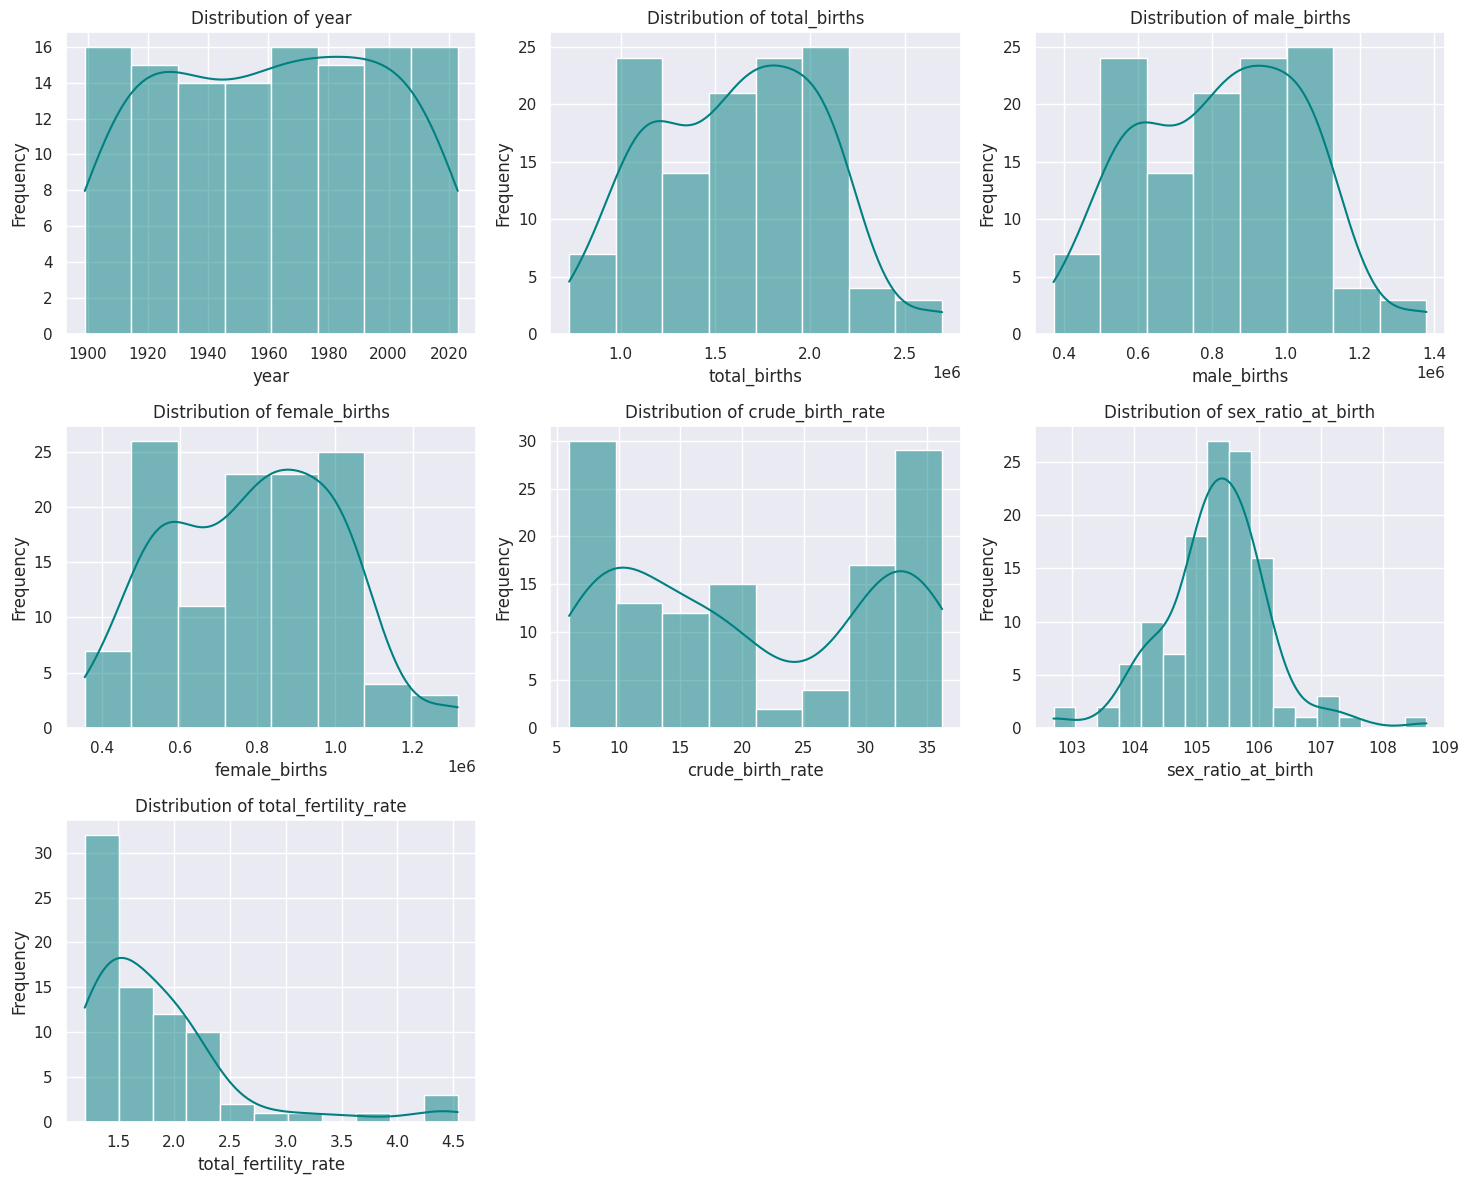

No categorical columns found (or all have high cardinality).


In [15]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivairate Analysis

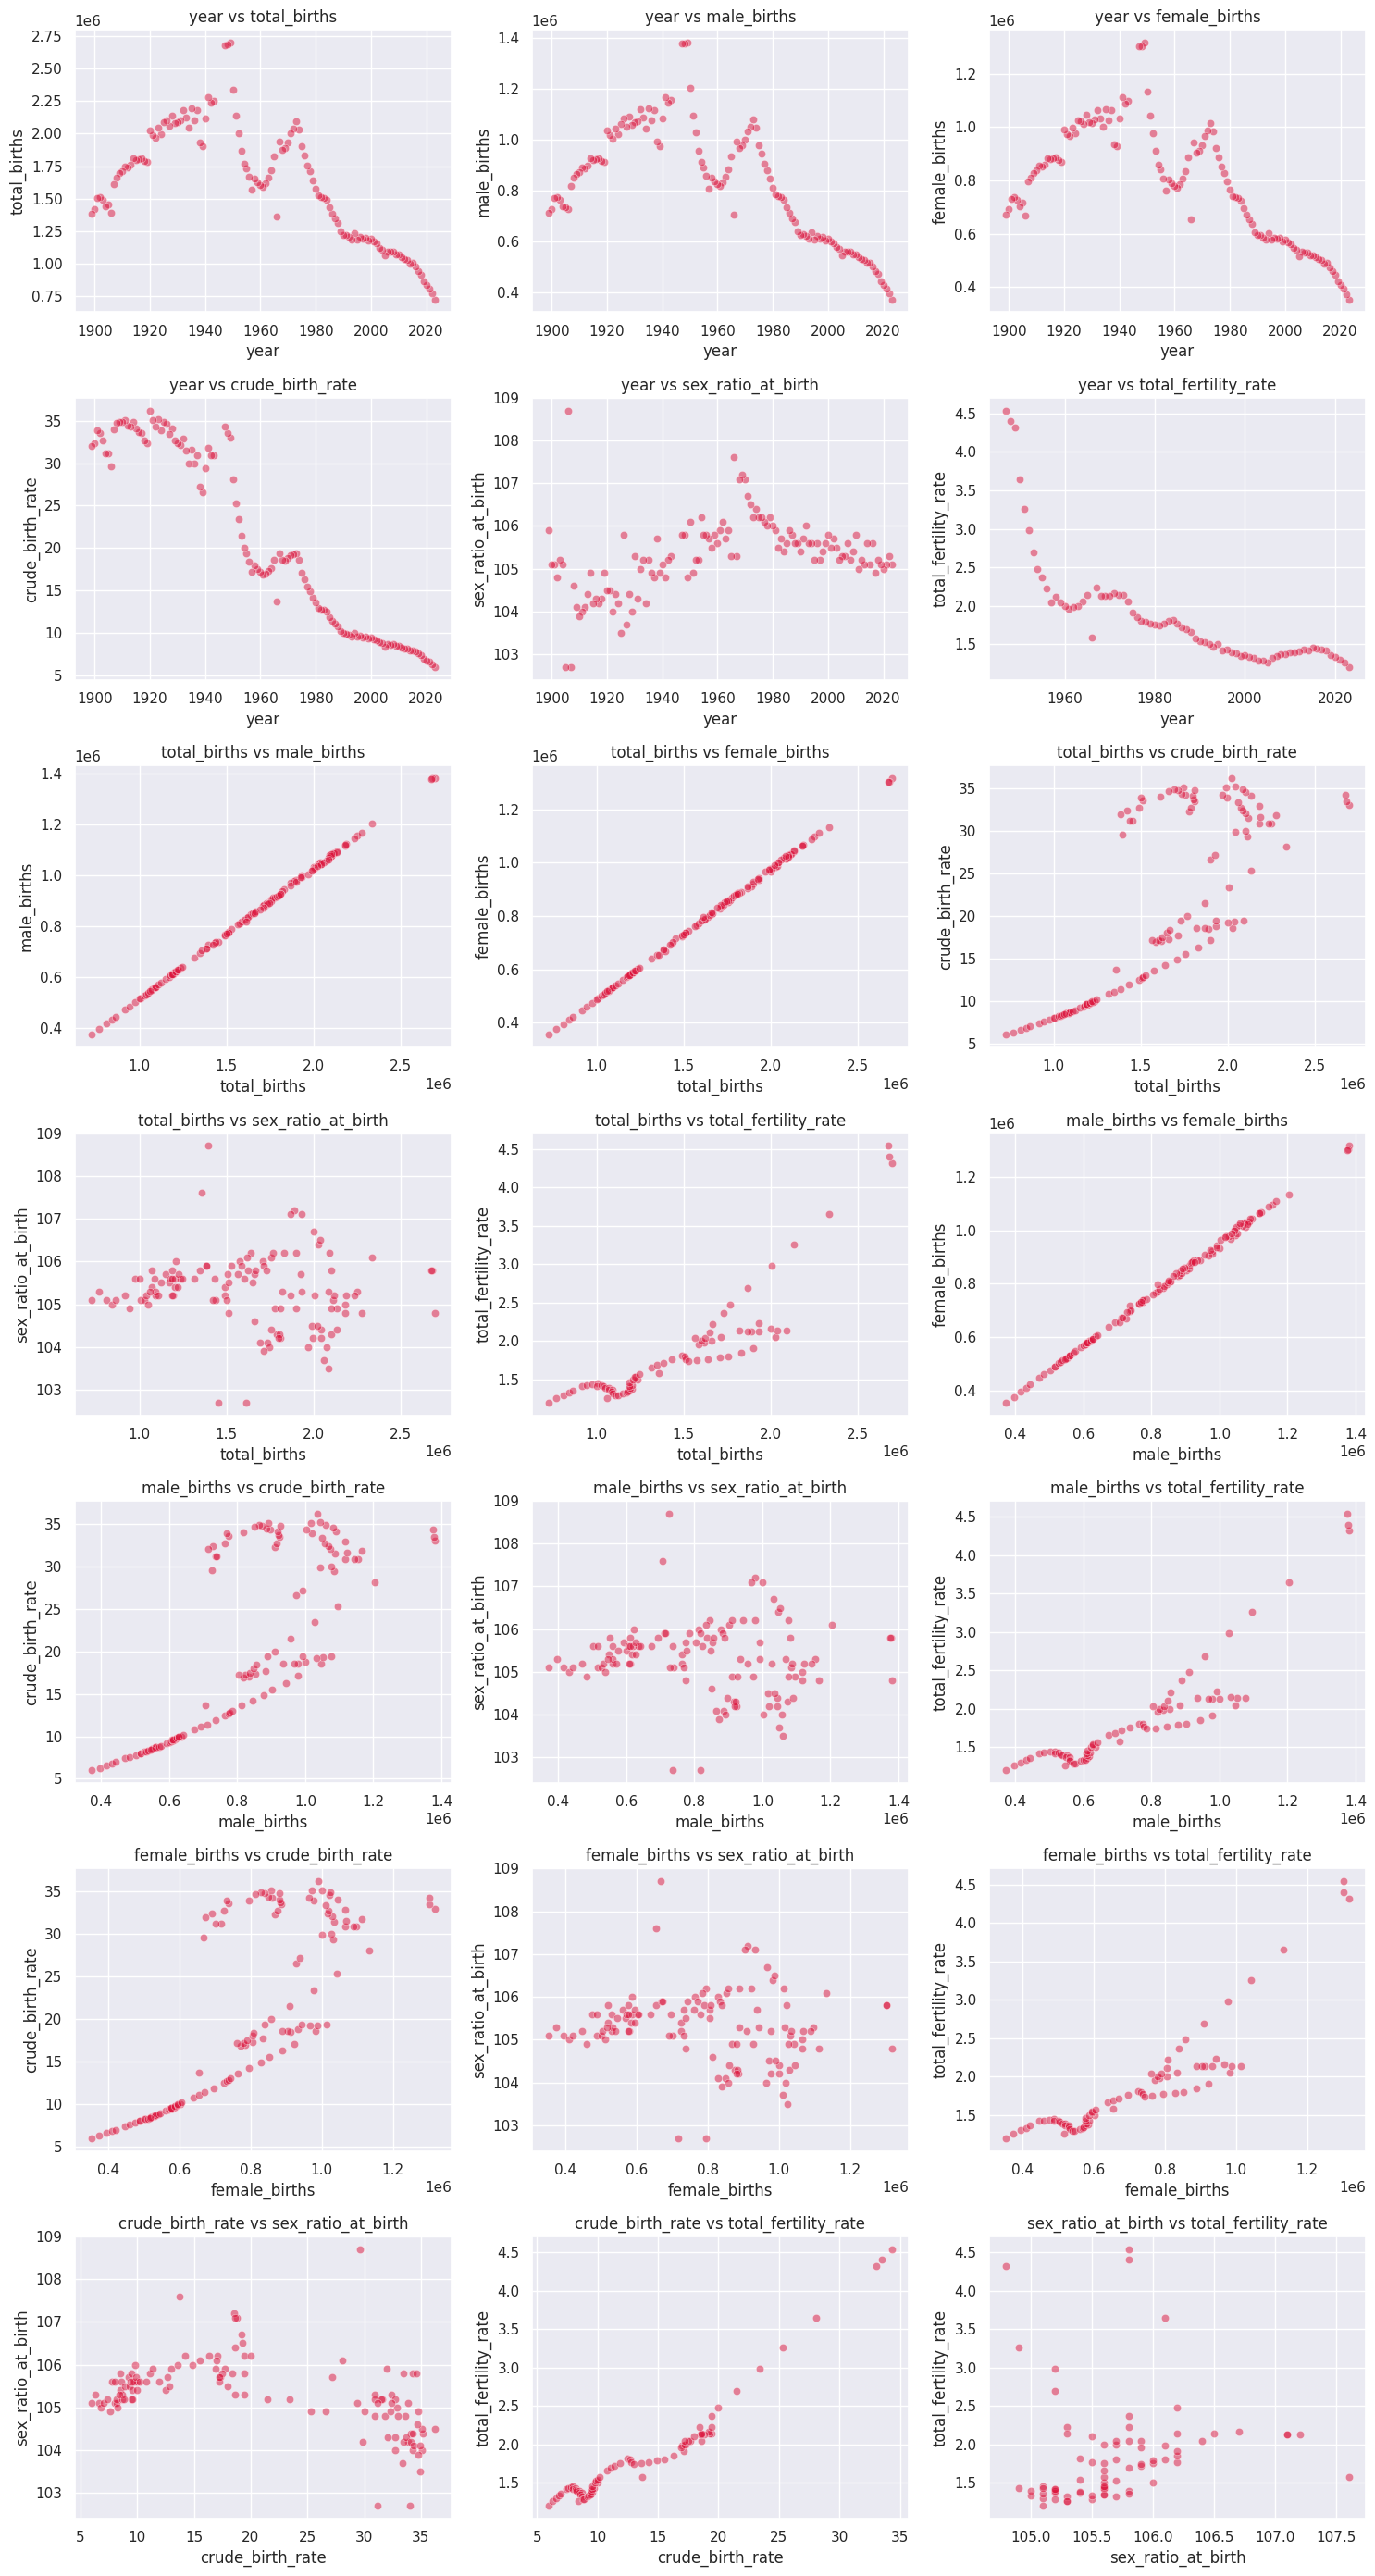

No categorical-numerical pairs found.


In [16]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

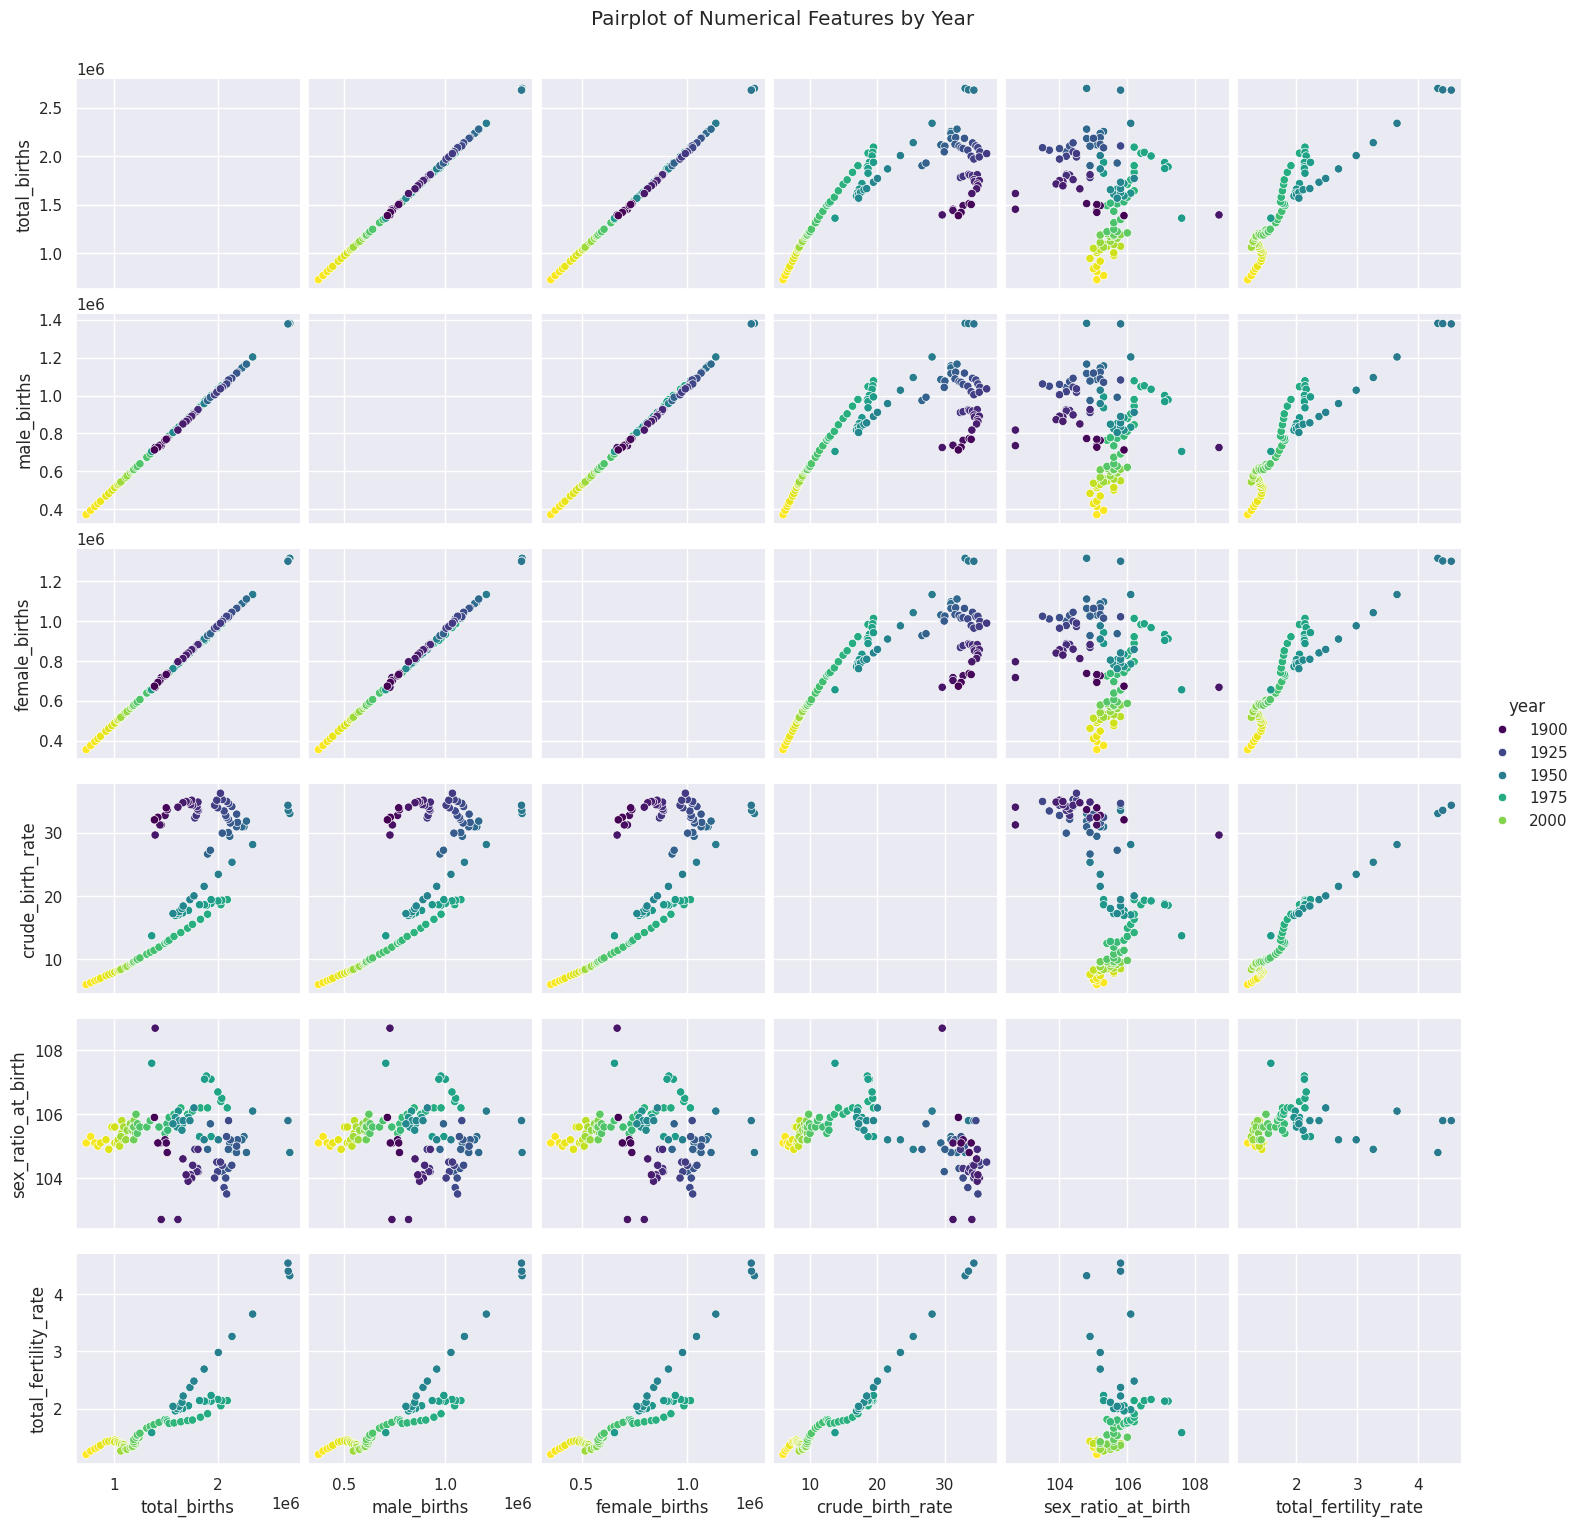

In [22]:
sns.pairplot(df.select_dtypes(include = np.number), hue='year', palette='viridis')
plt.suptitle('Pairplot of Numerical Features by Year', y=1.02)
plt.show()

# Heatmap

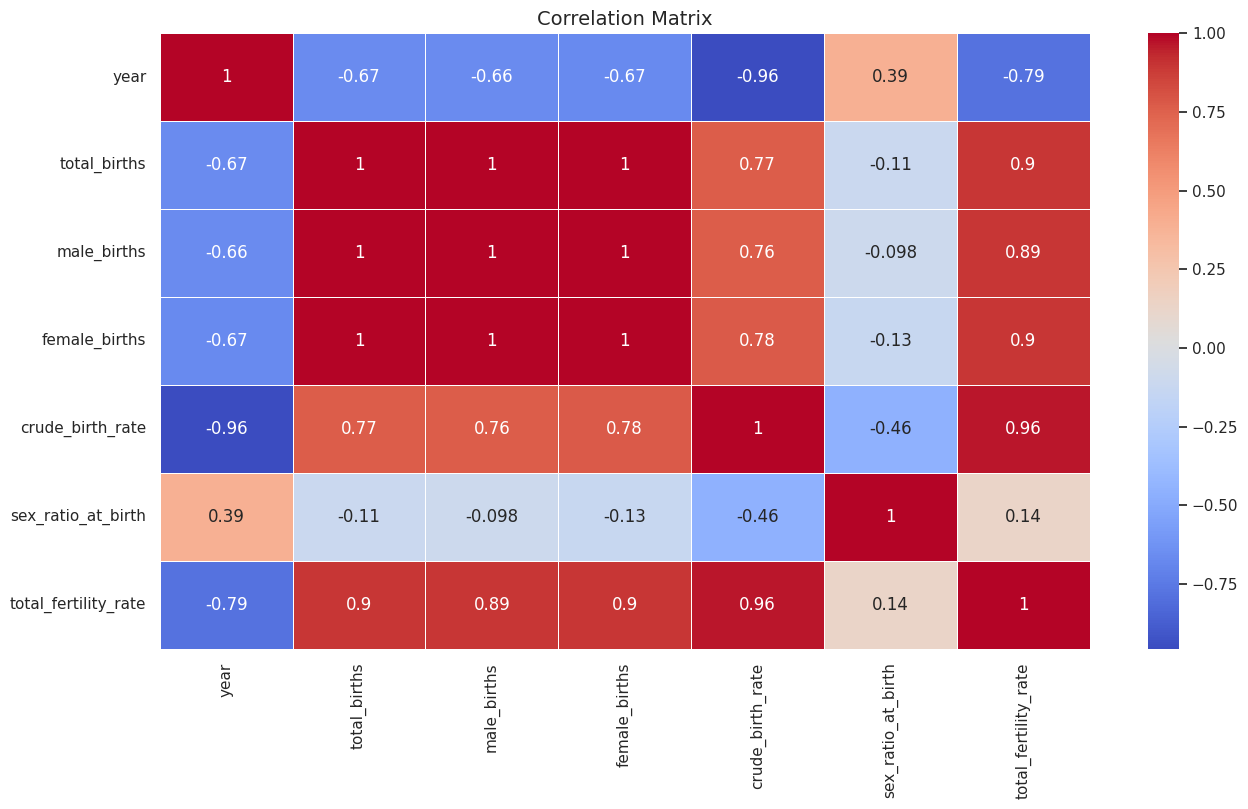

In [19]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis | Demographic Analysis

--- 1. THE BIOLOGICAL BASELINE TEST (ONE-SAMPLE T-TEST) ---
Historical Average Sex Ratio: 105.31
One-Sample T-Test P-Value: 1.1055e-04
🚨 Insight: Statistically significant deviation!
   -> Japan's historical sex ratio is mathematically different from the 105.0 biological standard.

--- 2. ISOLATING GENERATIONAL SHOCKS (Z-SCORE ANALYSIS) ---
📈 Found 4 extreme 'Baby Boom' years.
Peak Boom Years: [1950, 1949, 1948, 1947] ...
📉 Found 7 extreme 'Population Collapse' years.
Peak Collapse Years: [2021, 2020, 2019, 2018, 2017] ...


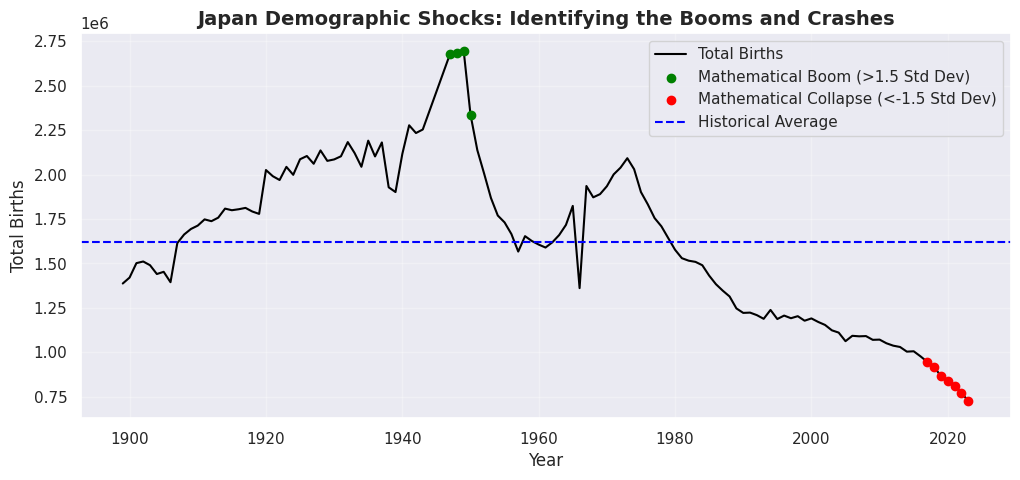


--- 3. MEASURING THE FERTILITY DECAY (PEARSON CORRELATION) ---
Pearson Correlation Coefficient (1950-Present): -0.8543
P-Value: 3.7990e-22
🚨 Insight: Severe negative correlation confirmed.
   -> THE DECAY IS STRUCTURAL: As time moves forward, the fertility rate is collapsing in a nearly straight downward line.


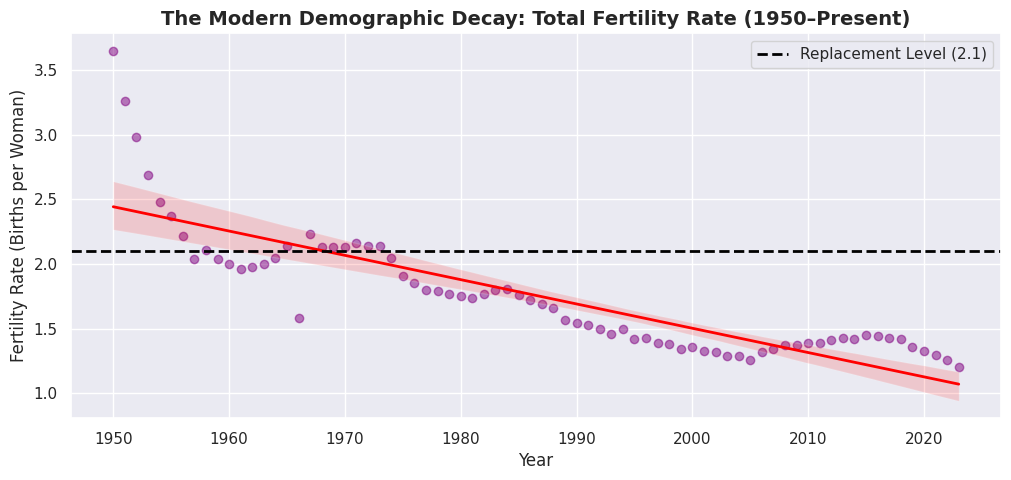

In [23]:
import scipy.stats as stats

print("--- 1. THE BIOLOGICAL BASELINE TEST (ONE-SAMPLE T-TEST) ---")
# The standard biological sex ratio at birth is 105 males per 100 females.
# Does Japan's historical average significantly differ from this human biological baseline?

# Dropping any nulls in the sex ratio column
ratio_data = df['sex_ratio_at_birth'].dropna()

# One-Sample T-Test against the population mean of 105
t_stat, p_val_ratio = stats.ttest_1samp(ratio_data, 105.0)

print(f"Historical Average Sex Ratio: {ratio_data.mean():.2f}")
print(f"One-Sample T-Test P-Value: {p_val_ratio:.4e}")

if p_val_ratio < 0.05:
    print(" Insight: Statistically significant deviation!")
    print(" -> Japan's historical sex ratio is mathematically different from the 105.0 biological standard.")
else:
    print(" Insight: Japan's birth ratio perfectly follows standard human biology (approx. 105 boys per 100 girls).")


print("\n--- 2. ISOLATING GENERATIONAL SHOCKS (Z-SCORE ANALYSIS) ---")
# Demographers look for "Regime Shifts" (sudden spikes or crashes).
# We are calculating the Z-score of 'total_births' to mathematically isolate the Baby Booms.

# Calculating how many Standard Deviations each year's births are from the historical average
mean_births = df['total_births'].mean()
std_births = df['total_births'].std()

df['Birth_Z_Score'] = (df['total_births'] - mean_births) / std_births

# Define an "Extreme Anomaly" as any year with a Z-Score > 1.5 (Massive Boom)
# or < -1.5 (Massive Collapse)
booms = df[df['Birth_Z_Score'] > 1.5]
collapses = df[df['Birth_Z_Score'] < -1.5]

print(f"📈 Found {len(booms)} extreme 'Baby Boom' years.")
if len(booms) > 0:
    print("Peak Boom Years:", booms['year'].tolist()[:5], "...")

print(f"📉 Found {len(collapses)} extreme 'Population Collapse' years.")
if len(collapses) > 0:
    print("Peak Collapse Years:", collapses['year'].tolist()[-5:], "...")

# Visualizing the Demographic Shocks
plt.figure(figsize=(12, 5))
plt.plot(df['year'], df['total_births'], color='black', label='Total Births')
plt.scatter(booms['year'], booms['total_births'], color='green', label='Mathematical Boom (>1.5 Std Dev)', zorder=5)
plt.scatter(collapses['year'], collapses['total_births'], color='red', label='Mathematical Collapse (<-1.5 Std Dev)', zorder=5)
plt.axhline(mean_births, color='blue', linestyle='--', label='Historical Average')
plt.title('Japan Demographic Shocks: Identifying the Booms and Crashes', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Births', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 3. MEASURING THE FERTILITY DECAY (PEARSON CORRELATION) ---")
# The replacement level fertility rate is 2.1 (the number of children a woman must have to keep the population stable).
# We will test the mathematical correlation between Time (Years) and Fertility Rate.

# Filtering the data to the modern era (Post-WWII / 1950 onwards) to measure the current crisis
modern_era = df[df['year'] >= 1950].copy()
corr_data = modern_era[['year', 'total_fertility_rate']].dropna()

corr_coef, p_val_fertility = stats.pearsonr(corr_data['year'], corr_data['total_fertility_rate'])

print(f"Pearson Correlation Coefficient (1950-Present): {corr_coef:.4f}")
print(f"P-Value: {p_val_fertility:.4e}")

if p_val_fertility < 0.05:
    print(" Insight: Severe negative correlation confirmed.")
    if corr_coef < -0.7:
        print(" -> THE DECAY IS STRUCTURAL: As time moves forward, the fertility rate is collapsing in a nearly straight downward line.")

# Visualizing the Fertility Crisis against the 2.1 Replacement Rate
plt.figure(figsize=(12, 5))
sns.regplot(x='year', y='total_fertility_rate', data=corr_data, scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'red', 'linewidth':2})
plt.axhline(2.1, color='black', linestyle='--', linewidth=2, label='Replacement Level (2.1)')
plt.title('The Modern Demographic Decay: Total Fertility Rate (1950–Present)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Fertility Rate (Births per Woman)', fontsize=12)
plt.legend()
plt.show()

# Time-Series Analysis | Forcasting Momentum Analysis

--- 1. THE VELOCITY OF COLLAPSE (YOY MOMENTUM) ---


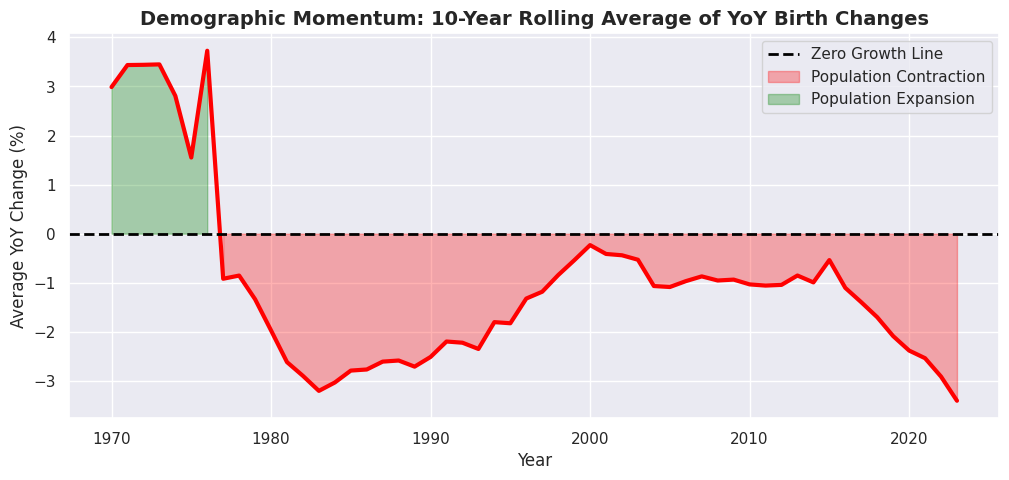

✅ Momentum calculated. Notice how the line stays permanently submerged below zero in recent decades.

--- 2. STRUCTURAL BREAK DETECTION (ROLLING VOLATILITY) ---


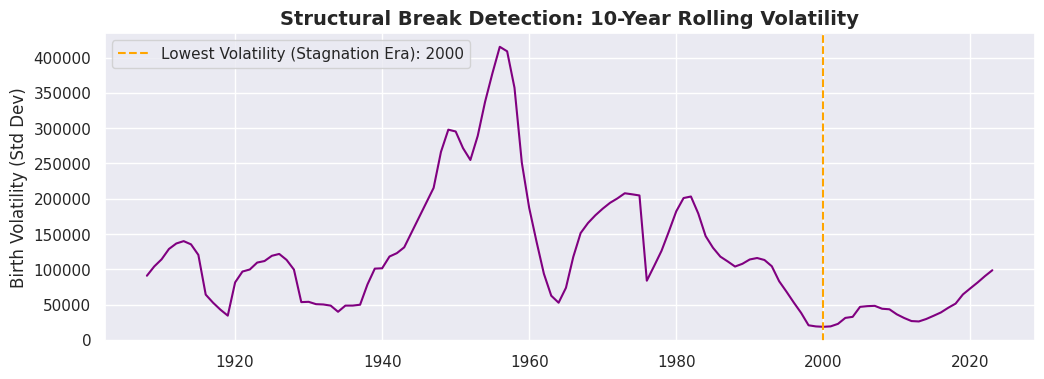


--- 3. ARIMA TIME SERIES FORECASTING (PROJECTIONS TO 2043) ---
🔮 ARIMA Statistical Projection for 2043: 746,134 births.


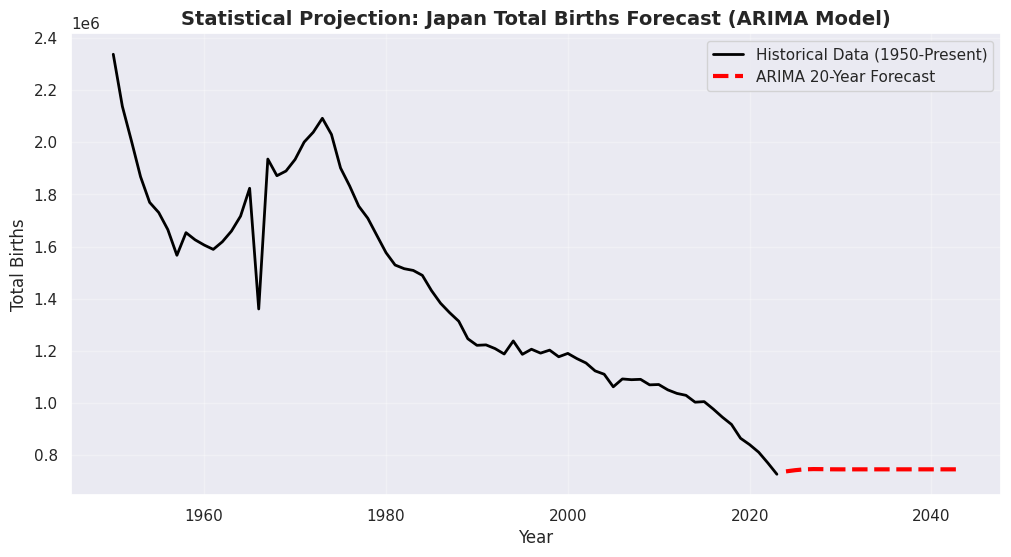

In [24]:
from statsmodels.tsa.arima.model import ARIMA

print("--- 1. THE VELOCITY OF COLLAPSE (YOY MOMENTUM) ---")
# The decline isn't just a straight line; the rate of decline is accelerating.
# We are calculating the Year-over-Year (YoY) percentage change in total births.

# Sorting chronologically just to be safe
df = df.sort_values('year').reset_index(drop=True)

# Calculating YoY percentage change
df['YoY_Birth_Change_%'] = df['total_births'].pct_change() * 100

# We are using a 10-year rolling average to smooth out the noise and see the true momentum
df['10_Year_Momentum'] = df['YoY_Birth_Change_%'].rolling(window=10).mean()

# we are looking at the modern era (Post-1970)
modern_momentum = df[df['year'] >= 1970]

plt.figure(figsize=(12, 5))
plt.plot(modern_momentum['year'], modern_momentum['10_Year_Momentum'], color='red', linewidth=3)
plt.axhline(0, color='black', linestyle='--', linewidth=2, label='Zero Growth Line')
plt.title('Demographic Momentum: 10-Year Rolling Average of YoY Birth Changes', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average YoY Change (%)', fontsize=12)
plt.fill_between(modern_momentum['year'], modern_momentum['10_Year_Momentum'], 0,
                 where=(modern_momentum['10_Year_Momentum'] < 0), color='red', alpha=0.3, label='Population Contraction')
plt.fill_between(modern_momentum['year'], modern_momentum['10_Year_Momentum'], 0,
                 where=(modern_momentum['10_Year_Momentum'] > 0), color='green', alpha=0.3, label='Population Expansion')
plt.legend()
plt.show()

print("✅ Momentum calculated. Notice how the line stays permanently submerged below zero in recent decades.")


print("\n--- 2. STRUCTURAL BREAK DETECTION (ROLLING VOLATILITY) ---")
# A "Structural Break" is a period where the data's fundamental behavior permanently changes.
# We can find this by tracking the rolling 10-year standard deviation (volatility).

df['Rolling_Volatility'] = df['total_births'].rolling(window=10).std()

# Finding the year where volatility suddenly spiked or dropped to historical lows
break_year = df.loc[df['Rolling_Volatility'].idxmin(), 'year']

plt.figure(figsize=(12, 4))
plt.plot(df['year'], df['Rolling_Volatility'], color='purple')
plt.axvline(break_year, color='orange', linestyle='--', label=f'Lowest Volatility (Stagnation Era): {break_year}')
plt.title('Structural Break Detection: 10-Year Rolling Volatility', fontsize=14, fontweight='bold')
plt.ylabel('Birth Volatility (Std Dev)')
plt.legend()
plt.show()


print("\n--- 3. ARIMA TIME SERIES FORECASTING (PROJECTIONS TO 2043) ---")
# We will build an ARIMA (AutoRegressive Integrated Moving Average) model.
# This algorithm uses the dataset's own historical lags and moving averages to project the future.

# We will train the model strictly on post-WWII data (1950 onwards) to avoid 1900s historical noise
train_data = df[df['year'] >= 1950]['total_births'].values

# Defining the ARIMA parameters (p=5 autoregressive lags, d=1 degree of differencing, q=0 moving average window)
# In a production environment, we would use grid-search to optimize (p,d,q).
arima_model = ARIMA(train_data, order=(5, 1, 0))
fitted_model = arima_model.fit()

# Forecasting the next 20 years
forecast_steps = 20
forecast = fitted_model.forecast(steps=forecast_steps)

# Creating future years array
last_year = df['year'].max()
future_years = np.arange(last_year + 1, last_year + 1 + forecast_steps)

print(f"🔮 ARIMA Statistical Projection for {future_years[-1]}: {int(forecast[-1]):,} births.")

# Visualize the historical data + the 20-year projection
plt.figure(figsize=(12, 6))
# Plot actual history
plt.plot(df[df['year'] >= 1950]['year'], train_data, color='black', label='Historical Data (1950-Present)', linewidth=2)
# Plot forecast
plt.plot(future_years, forecast, color='red', linestyle='--', label='ARIMA 20-Year Forecast', linewidth=3)

plt.title('Statistical Projection: Japan Total Births Forecast (ARIMA Model)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Births', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Non-Parametic & Seqnentical Diagnostics

--- 1. NON-PARAMETRIC TREND TESTING (KENDALL'S TAU) ---
Kendall's Tau Coefficient: -0.8916
P-Value: 3.7662e-29
🚨 Insight: Statistically significant monotonic trend detected.
   -> The Crude Birth Rate is mathematically locked in a persistent, downward trajectory.


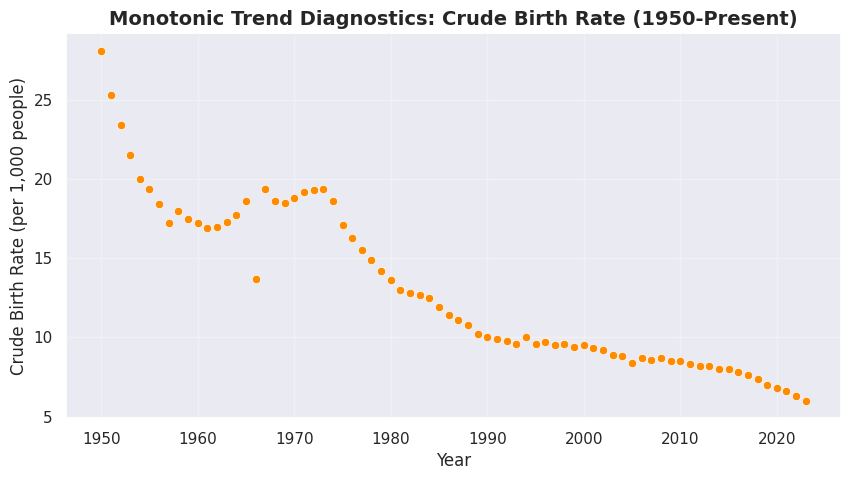


--- 2. TEMPORAL MEMORY DIAGNOSTICS (LJUNG-BOX TEST) ---
Ljung-Box Test P-Value (Lag 10): 3.4230e-159
🚨 Insight: Strong Autocorrelation detected. The Null Hypothesis of independence is rejected.
   -> Demographic momentum is highly dependent; a collapse today mathematically guarantees a collapse tomorrow.


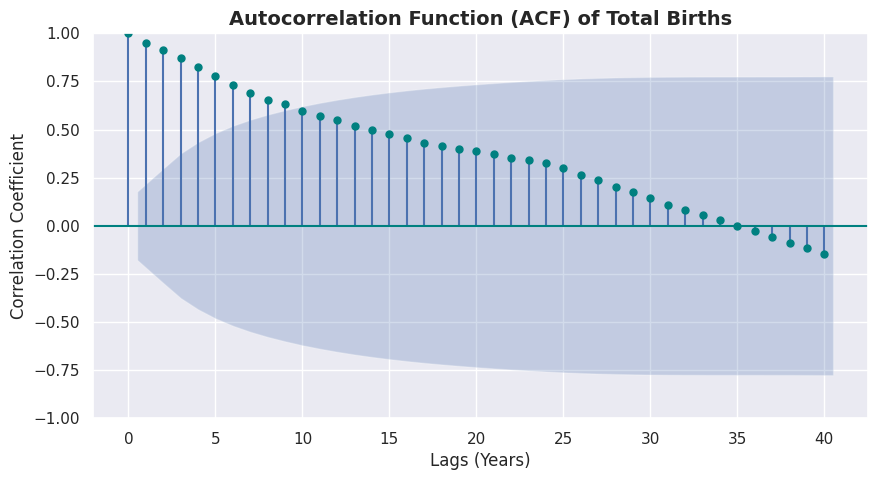


--- 3. DISTRIBUTIONAL PARADIGM SHIFT (KOLMOGOROV-SMIRNOV TEST) ---
K-S Statistic: nan
P-Value: nan


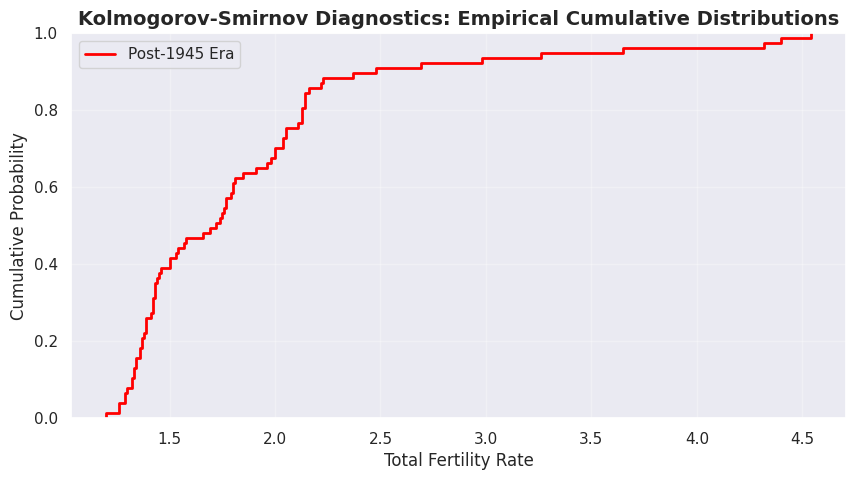

In [25]:
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

print("--- 1. NON-PARAMETRIC TREND TESTING (KENDALL'S TAU) ---")
# The decline in the Crude Birth Rate is monotonic (consistently decreasing),
# even if it does not follow a perfectly straight linear path.
# We use Kendall's Tau, which does not assume the data is normally distributed.

modern_demographics = df[df['year'] >= 1950].copy()
tau_coef, p_val_tau = stats.kendalltau(modern_demographics['year'], modern_demographics['crude_birth_rate'])

print(f"Kendall's Tau Coefficient: {tau_coef:.4f}")
print(f"P-Value: {p_val_tau:.4e}")

if p_val_tau < 0.05:
    print("🚨 Insight: Statistically significant monotonic trend detected.")
    if tau_coef < 0:
        print("   -> The Crude Birth Rate is mathematically locked in a persistent, downward trajectory.")

# Visualizing the Monotonic Decline
plt.figure(figsize=(10, 5))
sns.scatterplot(x='year', y='crude_birth_rate', data=modern_demographics, color='darkorange')
plt.title("Monotonic Trend Diagnostics: Crude Birth Rate (1950-Present)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Crude Birth Rate (per 1,000 people)")
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 2. TEMPORAL MEMORY DIAGNOSTICS (LJUNG-BOX TEST) ---")
# Time series data often exhibits autocorrelation (past values influence future values).
# The Ljung-Box test determines if the residuals of our data are independently distributed or if temporal memory exists.

# We are testing the first 10 lags of the total births sequence
ljung_box_results = acorr_ljungbox(df['total_births'].dropna(), lags=[10], return_df=True)
p_val_lb = ljung_box_results['lb_pvalue'].iloc[0]

print(f"Ljung-Box Test P-Value (Lag 10): {p_val_lb:.4e}")

if p_val_lb < 0.05:
    print("🚨 Insight: Strong Autocorrelation detected. The Null Hypothesis of independence is rejected.")
    print("   -> Demographic momentum is highly dependent; a collapse today mathematically guarantees a collapse tomorrow.")

# Visualizing the Autocorrelation Function (ACF)
plt.figure(figsize=(10, 5))
plot_acf(df['total_births'].dropna(), lags=40, alpha=0.05, ax=plt.gca(), color='teal')
plt.title("Autocorrelation Function (ACF) of Total Births", fontsize=14, fontweight='bold')
plt.xlabel("Lags (Years)")
plt.ylabel("Correlation Coefficient")
plt.show()


print("\n--- 3. DISTRIBUTIONAL PARADIGM SHIFT (KOLMOGOROV-SMIRNOV TEST) ---")
# The demographic landscape of Pre-WWII Japan is fundamentally a different
# mathematical distribution than Post-WWII Japan.
# The Two-Sample K-S test compares the cumulative distribution functions of two samples.

# Splitting the dataset into Pre-1945 and Post-1945
pre_ww2 = df[df['year'] < 1945]['total_fertility_rate'].dropna()
post_ww2 = df[df['year'] >= 1945]['total_fertility_rate'].dropna()

# Running the K-S Test
ks_stat, p_val_ks = stats.ks_2samp(pre_ww2, post_ww2)

print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-Value: {p_val_ks:.4e}")

if p_val_ks < 0.05:
    print("🚨 Insight: The Null Hypothesis that the two eras share the same distribution is rejected.")
    print("   -> A permanent, structural paradigm shift occurred in Japanese fertility behavior post-1945.")

# Visualizing the Distributional Shift via Cumulative Density Functions (CDF)
plt.figure(figsize=(10, 5))
sns.ecdfplot(pre_ww2, label='Pre-1945 Era', color='blue', linewidth=2)
sns.ecdfplot(post_ww2, label='Post-1945 Era', color='red', linewidth=2)
plt.title("Kolmogorov-Smirnov Diagnostics: Empirical Cumulative Distributions", fontsize=14, fontweight='bold')
plt.xlabel("Total Fertility Rate")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
print("--- 1. ENGINEERING LAGGED FEATURES ---")
# Machine Learning algorithms need to look at the past to predict the future.
# We create "Lagged" features (e.g., what was the birth rate 1 year ago? 3 years ago?)

# Sortting chronologically to ensure data integrity
df = df.sort_values('year').reset_index(drop=True)

# Engineering Lagged variables for total_births and total_fertility_rate
df['Births_Lag_1Yr'] = df['total_births'].shift(1)
df['Births_Lag_3Yr'] = df['total_births'].shift(3)
df['Fertility_Lag_1Yr'] = df['total_fertility_rate'].shift(1)

print(" Engineered: Lagged historical features (t-1, t-3).")


print("\n--- 2. ENGINEERING ROLLING STATISTICS ---")
# Rolling statistics provide the algorithm with a mathematical sense of recent momentum and volatility.

# 5-Year Rolling Average (Smoothing out short-term noise)
df['Births_Rolling_Mean_5Yr'] = df['total_births'].rolling(window=5).mean()

# 5-Year Rolling Standard Deviation (Measuring demographic stability/volatility)
df['Births_Rolling_Std_5Yr'] = df['total_births'].rolling(window=5).std()

print(" Engineered: Rolling momentum and volatility features (5-Year Windows).")


print("\n--- 3. DEFINING THE TARGET VARIABLE ---")
# We want the model to predict the *Next Year's* total births.
# We shift the total_births column backwards by 1 to create our Target (Y).

df['Target_Next_Year_Births'] = df['total_births'].shift(-1)

# Dropping all NaN rows created by shifting and rolling windows
ml_df = df.dropna().copy()

print(" Engineered: Target_Next_Year_Births")
print(f"Final Machine Learning Dataset Shape: {ml_df.shape}")

# Previewing the engineered dataset
print("\n Feature Engineering Preview (Latest 5 Years):")
print(ml_df[['year', 'total_births', 'Births_Lag_1Yr', 'Births_Rolling_Mean_5Yr', 'Target_Next_Year_Births']].tail())

--- 1. ENGINEERING LAGGED FEATURES ---
 Engineered: Lagged historical features (t-1, t-3).

--- 2. ENGINEERING ROLLING STATISTICS ---
 Engineered: Rolling momentum and volatility features (5-Year Windows).

--- 3. DEFINING THE TARGET VARIABLE ---
 Engineered: Target_Next_Year_Births
Final Machine Learning Dataset Shape: (75, 17)

 Feature Engineering Preview (Latest 5 Years):
     year  total_births  Births_Lag_1Yr  Births_Rolling_Mean_5Yr  \
116  2018        918400        946146.0                 970223.6   
117  2019        865239        918400.0                 942549.6   
118  2020        840835        865239.0                 909572.4   
119  2021        811622        840835.0                 876448.4   
120  2022        770759        811622.0                 841371.0   

     Target_Next_Year_Births  
116                 865239.0  
117                 840835.0  
118                 811622.0  
119                 770759.0  
120                 727288.0  


--- 1. CHRONOLOGICAL TRAIN/TEST SPLIT ---
 Training Set: 1948 to 2007
 Testing Set: 2008 to 2022

--- 2. MODEL TRAINING (RANDOM FOREST REGRESSOR) ---
 Random Forest Model Successfully Trained.

--- 3. MODEL EVALUATION & DIAGNOSTICS ---
 Mean Absolute Error (MAE): 161,081 births
 Mean Absolute Percentage Error (MAPE): 18.76%
 -> Interpretation: The model's forward-looking predictions are accurate within a 18.76% margin of error.


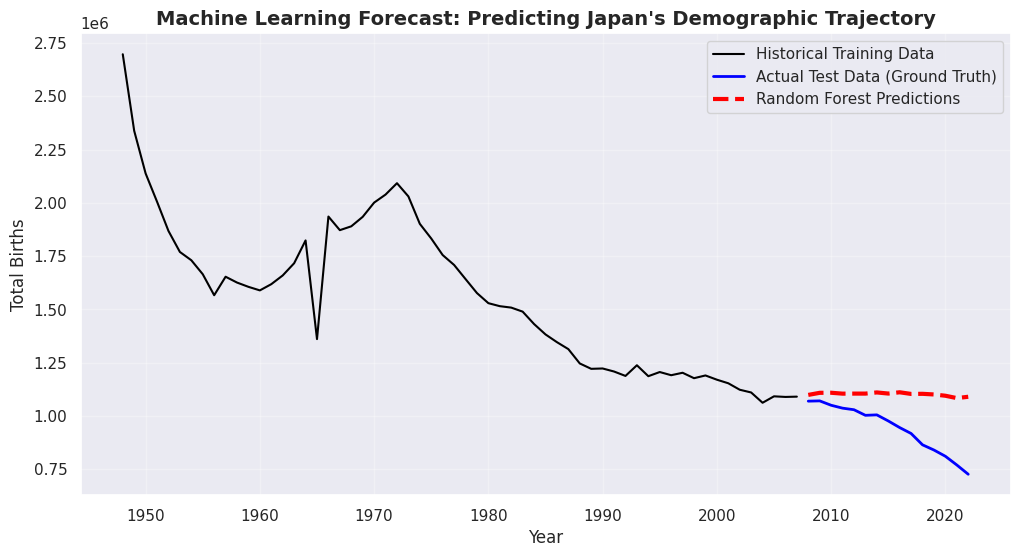


--- 4. FEATURE IMPORTANCE (ALGORITHMIC DRIVERS) ---


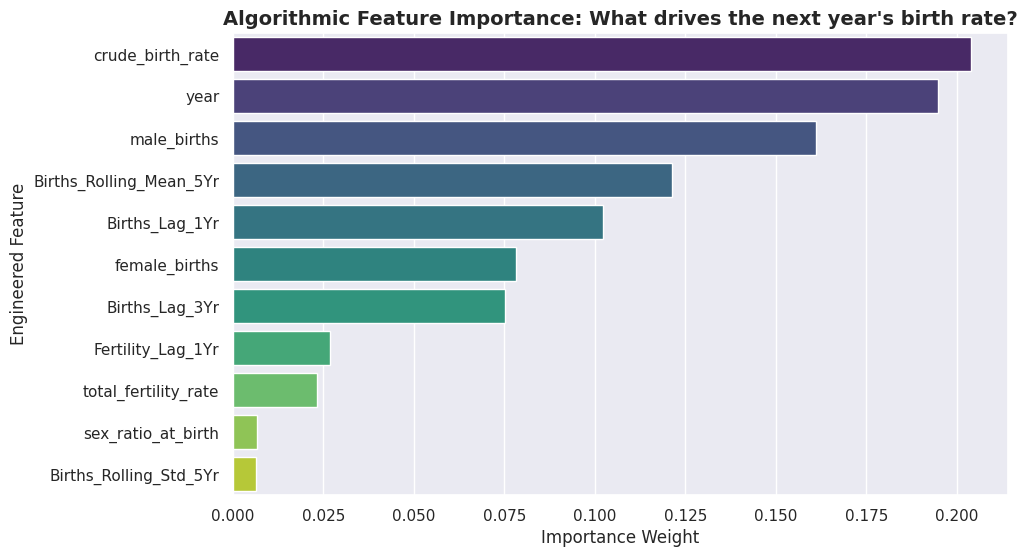

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

print("--- 1. CHRONOLOGICAL TRAIN/TEST SPLIT ---")
# Features (X) and Target (Y)
ml_features = ['year', 'male_births', 'female_births', 'crude_birth_rate',
               'sex_ratio_at_birth', 'total_fertility_rate', 'Births_Lag_1Yr',
               'Births_Lag_3Yr', 'Fertility_Lag_1Yr', 'Births_Rolling_Mean_5Yr',
               'Births_Rolling_Std_5Yr']

X = ml_df[ml_features]
y = ml_df['Target_Next_Year_Births']

# Splitting Chronologically: Train on history, Test on the final 15 years
test_window = 15
split_index = len(ml_df) - test_window

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f" Training Set: {X_train['year'].min()} to {X_train['year'].max()}")
print(f" Testing Set: {X_test['year'].min()} to {X_test['year'].max()}")


print("\n--- 2. MODEL TRAINING (RANDOM FOREST REGRESSOR) ---")
# Deploying a Random Forest Regressor to capture non-linear demographic shifts.
rf_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

print(" Random Forest Model Successfully Trained.")


print("\n--- 3. MODEL EVALUATION & DIAGNOSTICS ---")
# Predictions on the unseen testing data
ml_predictions = rf_model.predict(X_test)

# Calculating evaluation metrics
mae = mean_absolute_error(y_test, ml_predictions)
mape = mean_absolute_percentage_error(y_test, ml_predictions) * 100

print(f" Mean Absolute Error (MAE): {mae:,.0f} births")
print(f" Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f" -> Interpretation: The model's forward-looking predictions are accurate within a {mape:.2f}% margin of error.")

# Visualizing Model Performance (Actual vs. Predicted)
plt.figure(figsize=(12, 6))
plt.plot(X_train['year'], y_train, color='black', label='Historical Training Data')
plt.plot(X_test['year'], y_test, color='blue', linewidth=2, label='Actual Test Data (Ground Truth)')
plt.plot(X_test['year'], ml_predictions, color='red', linestyle='--', linewidth=3, label='Random Forest Predictions')

plt.title('Machine Learning Forecast: Predicting Japan\'s Demographic Trajectory', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Births', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 4. FEATURE IMPORTANCE (ALGORITHMIC DRIVERS) ---")
# Extracting the mathematical weights to see which features drove the algorithm's decisions
importances = pd.Series(rf_model.feature_importances_, index=ml_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Algorithmic Feature Importance: What drives the next year\'s birth rate?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Weight', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You